# Performance validation for ACA coordinate transform update PR#202

This looks at timing and accuracy.

In [1]:
import sys

sys.path.insert(0, "..")

from chandra_aca import transform
import astropy.table as apt
import matplotlib.pyplot as plt
import matplotlib.style
import numpy as np
matplotlib.style.use("bmh")
# %matplotlib inline

In [2]:
# Configure matplotlib for smaller file sizes
plt.rcParams["figure.dpi"] = 72  # Lower DPI
plt.rcParams["savefig.dpi"] = 72  # Lower DPI for saved figures
%config InlineBackend.figure_format = 'jpg'

### Timing for scalar case

In [3]:
row, col = 100, 200
yag, zag = 1000, 2000


In [4]:
transform.yagzag_to_pixels(yag, zag)
transform.pixels_to_yagzag(row, col);

In [5]:
%timeit transform.yagzag_to_pixels(yag, zag, flight=True)

6.3 μs ± 81.1 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [6]:
%timeit transform.pixels_to_yagzag(row, col, flight=True)

5.18 μs ± 58.7 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [7]:
%timeit transform.yagzag_to_pixels(yag, zag, flight=False)

6.42 μs ± 141 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [8]:
%timeit transform.pixels_to_yagzag(row, col, flight=False)

5.2 μs ± 59.2 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### Timing for vector case

In [9]:
row, col = np.linspace(-100, 100, 1000), np.linspace(-200, 200, 1000)
yag, zag = np.linspace(-1000, 1000, 1000), np.linspace(-2000, 2000, 1000)


In [10]:
transform.yagzag_to_pixels(yag, zag)
transform.pixels_to_yagzag(row, col);

In [11]:
%timeit transform.yagzag_to_pixels(yag, zag, flight=True)

58.9 μs ± 790 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [12]:
%timeit transform.pixels_to_yagzag(row, col, flight=True)

15.6 μs ± 189 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [13]:
%timeit transform.yagzag_to_pixels(yag, zag, flight=False)

58.6 μs ± 241 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [14]:
%timeit transform.pixels_to_yagzag(row, col, flight=False)

15.7 μs ± 135 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### Accuracy of transforms

In [15]:
star_obss = apt.Table.read("../chandra_aca/tests/data/star_obs_2020.fits.gz")


In [16]:
def dist(x1, y1, x2, y2):
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

In [17]:
yag_obss = []
zag_obss = []
for star_obs in star_obss:
    yag_obs, zag_obs = transform.pixels_to_yagzag(
        star_obs["row_obs"], star_obs["col_obs"], t_aca=star_obs["t_aca"], pix_zero_loc="center")
    yag_obss.append(yag_obs)
    zag_obss.append(zag_obs)

In [18]:
dy = yag_obss - star_obss["yag_star"]
dz = zag_obss - star_obss["zag_star"]
print(np.mean(dy), np.mean(dz), np.std(dy), np.std(dz))

0.3130909018591204 0.17585130156169823 0.2767168965105467 0.21811226170184494


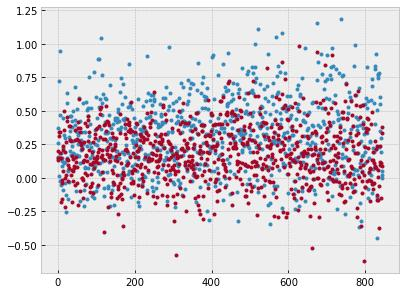

In [19]:
plt.plot(yag_obss - star_obss["yag_star"], '.');
plt.plot(zag_obss - star_obss["zag_star"], '.');

In [20]:
transform.pixels_to_yagzag(np.array([511.7]), np.array([-511.7]))

(array([-2497.64115098]), array([-2541.58884361]))

In [21]:
coeffs0 = transform.PIX_TO_ANG_FLIGHT[:, 0]
transform._poly_convert_numba(511.7, -511.7, coeffs0, t_aca=20.0)

np.float64(-1261859.9605738022)

In [22]:
t_aca = 20

In [23]:
yags, zags = np.meshgrid([-2000, 0, 2000], [-2000, 0, 2000])

In [24]:
rows, cols = transform.yagzag_to_pixels(yags, zags, t_aca=t_aca)
rows, cols

(array([[ 408.95183915,    5.39904376, -398.43759939],
        [ 408.08300404,    6.08840496, -396.1804519 ],
        [ 410.30160185,    6.74646107, -397.07602799]]),
 array([[-399.39831171, -397.22150746, -398.23195038],
        [   4.21615402,    4.92618564,    5.5816765 ],
        [ 407.79012145,  407.03928063,  409.36159752]]))

In [25]:
yags_rt, zags_rt = transform.pixels_to_yagzag(rows, cols, t_aca=t_aca)

In [26]:
yags - yags_rt

array([[-0.00556851, -0.00341848, -0.00942843],
       [-0.00045843,  0.01008816, -0.00015223],
       [ 0.00637373,  0.00348644,  0.00670114]])

In [27]:
zags - zags_rt

array([[ 0.00659019,  0.00028949, -0.00435407],
       [ 0.00300733,  0.00223477, -0.00351291],
       [ 0.00679155,  0.00125849, -0.00663026]])

In [28]:
%load_ext line_profiler

In [29]:
row = np.linspace(-100, 100, 1000)
col = np.linspace(-100, 100, 1000)


In [30]:
%timeit transform.yagzag_to_pixels(row, col, t_aca=t_aca)


36.9 μs ± 693 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [31]:
%timeit transform.yagzag_to_pixels(1.0, 2.0, t_aca=t_aca)


4.62 μs ± 177 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [32]:
%lprun -f transform._yagzag_to_pixels_by_inversion_newton transform.yagzag_to_pixels(row, col, t_aca=t_aca)


Timer unit: 1e-09 s

Total time: 6.2e-05 s
File: /Users/aldcroft/git/chandra_aca/validate/../chandra_aca/transform.py
Function: _yagzag_to_pixels_by_inversion_newton at line 354

Line #      Hits         Time  Per Hit   % Time  Line Contents
   354                                           def _yagzag_to_pixels_by_inversion_newton(yang, zang, t_aca, flight):
   355                                               """Use Newton iterations to transform yang/zang to row/col.
   356                                           
   357                                               This directly inverts ``pixels_to_yagzag`` using a fast fixed-Jacobian
   358                                               Newton update. Accuracy target is ~0.05 arcsec in y/z.
   359                                               """
   360                                           
   361         1          0.0      0.0      0.0      tol = 0.05
   362         1          0.0      0.0      0.0      max_iter = 6
   363 

In [33]:
%timeit transform.pixels_to_yagzag(1, 2, t_aca=t_aca, allow_bad=True)


4.5 μs ± 138 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [34]:
%lprun -f transform.pixels_to_yagzag transform.pixels_to_yagzag(1, 2, t_aca=t_aca, allow_bad=True)


Timer unit: 1e-09 s

Total time: 2.8e-05 s
File: /Users/aldcroft/git/chandra_aca/validate/../chandra_aca/transform.py
Function: pixels_to_yagzag at line 220

Line #      Hits         Time  Per Hit   % Time  Line Contents
   220                                           def pixels_to_yagzag(
   221                                               row, col, *, allow_bad=True, flight=False, t_aca=None, pix_zero_loc="edge"
   222                                           ):
   223                                               """
   224                                               Convert ACA row/column positions to ACA y-angle, z-angle.
   225                                           
   226                                               It is expected that the row and column input arguments have the same length.
   227                                           
   228                                               The ``pix_zero_loc`` parameter controls whether the input pixel values
   229